<a href="https://colab.research.google.com/github/karimamzghi/cifar10-cnn-classification-project/blob/main/baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!git clone https://github.com/karimamzghi/cifar10-cnn-classification-project.git
%cd cifar10-cnn-classification-project

Cloning into 'cifar10-cnn-classification-project'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 43 (delta 17), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 143.04 KiB | 7.95 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/cifar10-cnn-classification-project/cifar10-cnn-classification-project/cifar10-cnn-classification-project/cifar10-cnn-classification-project/cifar10-cnn-classification-project


# Project 1 - CNN Image Classification

# ***CNN*** Classification Project using CIFAR-10 DataSet

In [41]:
# Import numpy lib
import numpy as np

# Imports matptotlib lib
import matplotlib.pyplot as plt

# Imports tensorflow.Keras lib
import tensorflow.keras as keras
from keras import layers
from keras.datasets import cifar10
from keras.models import Sequential
from keras.utils import to_categorical
from keras.backend import clear_session
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD

# Imports custom files aka config files, etc
from src import config

In [42]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [43]:
print("x_train: ", x_train.shape)
print("y_train: ", y_train.shape)
print("x_test: ", x_test.shape)
print("y_test: ", y_test.shape)

x_train:  (50000, 32, 32, 3)
y_train:  (50000, 1)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 1)


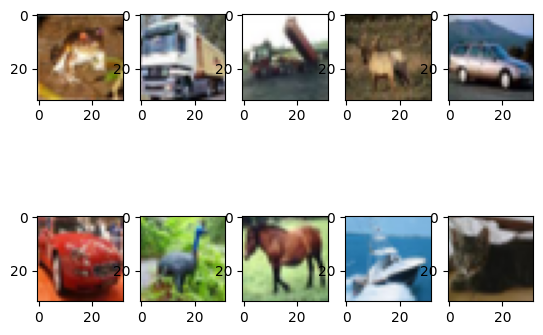

In [44]:
# Add image visualization utilities
for i in range(10):
	plt.subplot(2, 5, i + 1)
	plt.imshow(x_train[i])
plt.show()

In [45]:
# Feature Engineering: Hardcoding labels using one-hot encoding
print("Train Data before encoding: ", y_train[:10])
print("Test Data before encoding: ", y_test[:10])

# Perform one-hot encoding for 10 classes
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


print("\nTrain After encoding: ", y_train[:10])
print("Test Data after encoding: ", y_test[:10])


Train Data before encoding:  [[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]
Test Data before encoding:  [[3]
 [8]
 [8]
 [0]
 [6]
 [6]
 [1]
 [6]
 [3]
 [1]]

Train After encoding:  [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Test Data after encoding:  [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [46]:
# Normalising the data by dividing every pixel by 255.
# Image pixels from will displayed with values range from 0-1 instead of  0-255

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

print("Train Data after normalisation: ", x_train[:10])
print("Test Data after normalisation: ", x_test[:10])

print("x_train min:", x_train.min())
print("x_train max:", x_train.max())
print("x_train dtype:", x_train.dtype)

Train Data after normalisation:  [[[[0.23137255 0.24313726 0.24705882]
   [0.16862746 0.18039216 0.1764706 ]
   [0.19607843 0.1882353  0.16862746]
   ...
   [0.61960787 0.5176471  0.42352942]
   [0.59607846 0.49019608 0.4       ]
   [0.5803922  0.4862745  0.40392157]]

  [[0.0627451  0.07843138 0.07843138]
   [0.         0.         0.        ]
   [0.07058824 0.03137255 0.        ]
   ...
   [0.48235294 0.34509805 0.21568628]
   [0.46666667 0.3254902  0.19607843]
   [0.47843137 0.34117648 0.22352941]]

  [[0.09803922 0.09411765 0.08235294]
   [0.0627451  0.02745098 0.        ]
   [0.19215687 0.10588235 0.03137255]
   ...
   [0.4627451  0.32941177 0.19607843]
   [0.47058824 0.32941177 0.19607843]
   [0.42745098 0.28627452 0.16470589]]

  ...

  [[0.8156863  0.6666667  0.3764706 ]
   [0.7882353  0.6        0.13333334]
   [0.7764706  0.6313726  0.10196079]
   ...
   [0.627451   0.52156866 0.27450982]
   [0.21960784 0.12156863 0.02745098]
   [0.20784314 0.13333334 0.07843138]]

  [[0.705882

In [47]:
# Clear any previous TensorFlow models from memory as TensorFlow can accumulate unnecessary objects in memory,
# especially if we are creating many models while tuning hyperparameters.
clear_session()

In [48]:
# Build the CNN Model

# Initialize and define the model
sequential_model = keras.Sequential(
   [
       keras.Input(shape=config.INPUT_SHAPE),
       layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
       layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
       layers.MaxPooling2D(pool_size=(2, 2)),
       layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
       layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
       layers.MaxPooling2D(pool_size=(2, 2)),
       layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
       layers.MaxPooling2D(pool_size=(2, 2)),
       layers.Flatten(),
       layers.Dropout(0.5),
       layers.Dense(config.NUM_CLASSES, activation="softmax"),
   ]
)

# Display the model params
sequential_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,146 (402.91 KB)

 Trainable params: 103,146 (402.91 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric
sequential_model.compile(
    optimizer=config.ADAM_OP,
    loss=config.CATEGORICAL_CROSSENTROPY,
    metrics=[config.ACCURACY]
)